
# SHA-256 Transport Geometry — Companion Workbook

**Companion workbook for:**  
**_Exhaustive Analysis of SHA-256 Input Transport Geometry: State-Space Closure, Schedule-Graph Structure, and the Capacity-Gated Projection Law_**

This notebook is a **workbook**, not a paper replacement. It mirrors the paper’s proof chain and is designed to help the reader:

1. reproduce the exact transport bench,
2. inspect the direct state-space laws,
3. verify the $K/L/M$ closure,
4. switch basis into schedule space with $N/P$,
5. fit the capacity-gated projection law $R$,
6. connect the results back to the layered transport model.

The workbook is organized as a sequence of:
- **Context cells**
- **Exact measurement cells**
- **Interpretation checkpoints**
- **Exercises / extension prompts**

The paper’s structure is preserved:
$$
\text{Entry} \rightarrow \text{Branch} \rightarrow \text{Saturate} \rightarrow \text{Reset}
$$


In [1]:
# Optional: uncomment if this environment needs installs
# %pip install numpy matplotlib pandas

In [2]:
# Workbook config
USE_BLOCK = bytes(range(64))
BOOTSTRAP_RESAMPLES = 4000
PERMUTATION_COUNT = 10000
RANDOM_SEED = 42
np_random_seed = 42


## 1. Imports, rails, and low-level operators

In [3]:

import struct
import math
import numpy as np
import matplotlib.pyplot as plt

MASK32 = 0xFFFFFFFF

H0 = [
    0x6A09E667, 0xBB67AE85, 0x3C6EF372, 0xA54FF53A,
    0x510E527F, 0x9B05688C, 0x1F83D9AB, 0x5BE0CD19,
]

K = [
    0x428A2F98, 0x71374491, 0xB5C0FBCF, 0xE9B5DBA5, 0x3956C25B, 0x59F111F1, 0x923F82A4, 0xAB1C5ED5,
    0xD807AA98, 0x12835B01, 0x243185BE, 0x550C7DC3, 0x72BE5D74, 0x80DEB1FE, 0x9BDC06A7, 0xC19BF174,
    0xE49B69C1, 0xEFBE4786, 0x0FC19DC6, 0x240CA1CC, 0x2DE92C6F, 0x4A7484AA, 0x5CB0A9DC, 0x76F988DA,
    0x983E5152, 0xA831C66D, 0xB00327C8, 0xBF597FC7, 0xC6E00BF3, 0xD5A79147, 0x06CA6351, 0x14292967,
    0x27B70A85, 0x2E1B2138, 0x4D2C6DFC, 0x53380D13, 0x650A7354, 0x766A0ABB, 0x81C2C92E, 0x92722C85,
    0xA2BFE8A1, 0xA81A664B, 0xC24B8B70, 0xC76C51A3, 0xD192E819, 0xD6990624, 0xF40E3585, 0x106AA070,
    0x19A4C116, 0x1E376C08, 0x2748774C, 0x34B0BCB5, 0x391C0CB3, 0x4ED8AA4A, 0x5B9CCA4F, 0x682E6FF3,
    0x748F82EE, 0x78A5636F, 0x84C87814, 0x8CC70208, 0x90BEFFFA, 0xA4506CEB, 0xBEF9A3F7, 0xC67178F2,
]

def u32(x): return x & MASK32
def hw(x): return int((x & MASK32).bit_count())
def rotr(x, n): return ((x >> n) | (x << (32 - n))) & MASK32
def sigma0(x): return rotr(x, 7) ^ rotr(x, 18) ^ (x >> 3)
def sigma1(x): return rotr(x, 17) ^ rotr(x, 19) ^ (x >> 10)
def Sigma0(x): return rotr(x, 2) ^ rotr(x, 13) ^ rotr(x, 22)
def Sigma1(x): return rotr(x, 6) ^ rotr(x, 11) ^ rotr(x, 25)
def Ch(x, y, z): return (x & y) ^ (~x & z)
def Maj(x, y, z): return (x & y) ^ (x & z) ^ (y & z)

def flip_bit(block_bytes, bit):
    fb = bytearray(block_bytes)
    fb[bit // 8] ^= (1 << (7 - (bit % 8)))
    return bytes(fb)

print("Rails loaded.")
print("H0[0] =", hex(H0[0]))
print("K[0]  =", hex(K[0]), "K[63] =", hex(K[-1]))


Rails loaded.
H0[0] = 0x6a09e667
K[0]  = 0x428a2f98 K[63] = 0xc67178f2



### Checkpoint

The workbook uses the standard SHA-256 rails:
- initial state $H_0$
- round constants $K_0,\dots,K_{63}$

The paper’s transport claims only make sense if the implementation core is stable. This is the first place to verify that the bench is operating on the real SHA-256 structure rather than on a simplified toy machine.


## 2. Schedule engine and compression trace

In [4]:

def expand_schedule(block_bytes):
    W = list(struct.unpack(">16I", block_bytes))
    for i in range(16, 64):
        W.append(u32(sigma1(W[i - 2]) + W[i - 7] + sigma0(W[i - 15]) + W[i - 16]))
    return W

def compress_trace(block_bytes, iv=H0):
    W = expand_schedule(block_bytes)
    a, b, c, d, e, f, g, h = iv
    states = []
    carries = []
    for i in range(64):
        T1_raw = h + Sigma1(e) + Ch(e, f, g) + K[i] + W[i]
        T2_raw = Sigma0(a) + Maj(a, b, c)
        T1 = u32(T1_raw)
        e_new_r = d + T1
        a_new_r = T1 + u32(T2_raw)
        carry_ct = (1 if T1_raw > MASK32 else 0) + (1 if e_new_r > MASK32 else 0) + (1 if a_new_r > MASK32 else 0)
        h, g, f, e, d, c, b, a = g, f, e, u32(e_new_r), c, b, a, u32(a_new_r)
        states.append((a, b, c, d, e, f, g, h))
        carries.append(carry_ct)
    return W, states, carries

def state_xor_mask(s1, s2):
    return [a ^ b for a, b in zip(s1, s2)]

def mask_hw(mask):
    return sum(hw(w) for w in mask)

W_base, S_base, C_base = compress_trace(USE_BLOCK)
print("Schedule length:", len(W_base))
print("State rounds:", len(S_base))
print("First four W words:", [hex(x) for x in W_base[:4]])


Schedule length: 64
State rounds: 64
First four W words: ['0x10203', '0x4050607', '0x8090a0b', '0xc0d0e0f']



### Exercise 2.1

Inspect the first sixteen schedule words and compare them to the raw block bytes.  
Then inspect $W[16]$ through $W[20]$ and confirm that the recurrence
$$
W[t]=W[t-16]+\sigma_0(W[t-15])+W[t-7]+\sigma_1(W[t-2])\pmod{2^{32}}
$$
is already turning the direct message words into a recursive schedule field.


## 3. Direct intra-block transport law

In [5]:

def direct_word_transport(block0=USE_BLOCK):
    _, S0, C0 = compress_trace(block0)
    rows = []
    state_hw = np.zeros((16, 64), dtype=float)
    carry_d = np.zeros((16, 64), dtype=float)

    for k in range(16):
        bits = range(k * 32, (k + 1) * 32)
        for bit in bits:
            _, Sp, Cp = compress_trace(flip_bit(block0, bit))
            for r in range(64):
                state_hw[k, r] += mask_hw(state_xor_mask(S0[r], Sp[r]))
                carry_d[k, r] += abs(C0[r] - Cp[r])
        state_hw[k] /= 32.0
        carry_d[k] /= 32.0

        early = state_hw[k, :16].sum()
        sat_round = int(np.argmax(state_hw[k] >= 128)) if np.any(state_hw[k] >= 128) else int(np.argmax(state_hw[k]))
        rounds = np.arange(64, dtype=float)
        cc = float((carry_d[k] * rounds).sum() / carry_d[k].sum()) if carry_d[k].sum() > 0 else np.nan
        rows.append((k, early, sat_round, cc))
    return np.array(rows, dtype=float), state_hw, carry_d

direct_rows, direct_hw, direct_carry = direct_word_transport()
k = direct_rows[:, 0]
early = direct_rows[:, 1]
sat = direct_rows[:, 2]
cc = direct_rows[:, 3]

m_early, b_early = np.polyfit(k[:12], early[:12], 1)
m_sat, b_sat = np.polyfit(k, sat, 1)
m_cc, b_cc = np.polyfit(k, cc, 1)

print(f"Inner early slope W[0..11]: {m_early:.6f} bits/word")
print(f"Saturation slope W[0..15]:  {m_sat:.6f} rounds/word")
print(f"Carry-centroid slope:       {m_cc:.6f} rounds/word")


Inner early slope W[0..11]: -126.739729 bits/word
Saturation slope W[0..15]:  0.782353 rounds/word
Carry-centroid slope:       0.464739 rounds/word


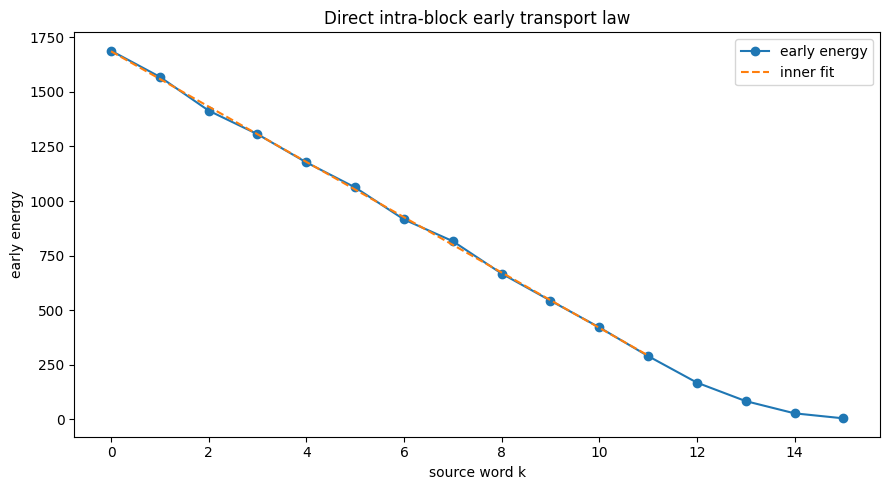

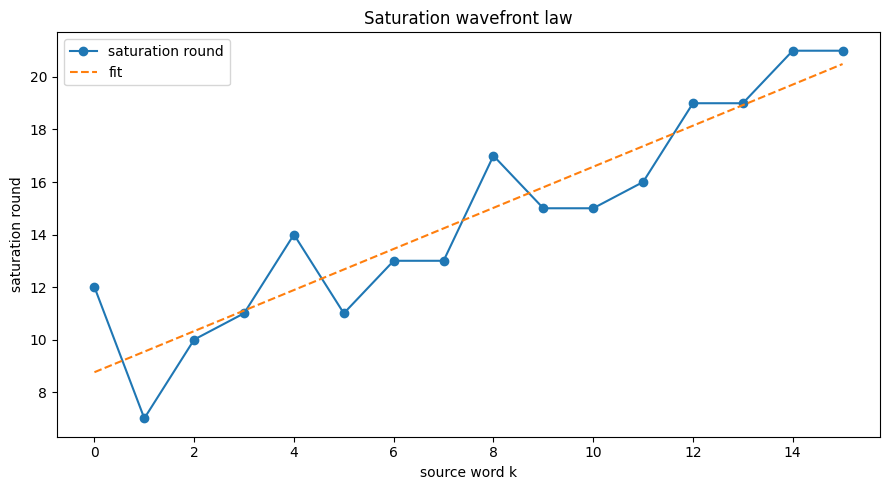

In [6]:

plt.figure(figsize=(9, 5))
plt.plot(k, early, marker="o", label="early energy")
plt.plot(k[:12], m_early*k[:12] + b_early, linestyle="--", label="inner fit")
plt.xlabel("source word k")
plt.ylabel("early energy")
plt.title("Direct intra-block early transport law")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(k, sat, marker="o", label="saturation round")
plt.plot(k, m_sat*k + b_sat, linestyle="--", label="fit")
plt.xlabel("source word k")
plt.ylabel("saturation round")
plt.title("Saturation wavefront law")
plt.legend()
plt.tight_layout()
plt.show()



### Interpretation checkpoint

The paper’s direct-law section is built on three linked observations:

$$
E_{\mathrm{early}}(k)\approx 105.27-7.865k
$$

$$
r_{\mathrm{sat}}(k)\approx k+5
$$

$$
C_{\mathrm{carry}}(k)\approx C_0+\gamma k,\qquad \gamma\approx 0.4648
$$

This is the empirical reason the paper says **word index is injection time**.
The point is not just that later words do “less”; it is that they do less in a nearly affine timing law.


## 4. Simultaneity nulls: cross-block and bit-scale


The direct law only appears when entry is staggered.

The transport principle tested in the paper is:
$$
\tau_i\neq\tau_j \Longrightarrow G\neq 0,
$$
$$
\tau_i=\tau_j\ \forall i,j \Longrightarrow G\approx 0.
$$

In the paper, this shows up in two null zones:
1. across the chaining boundary,
2. inside a single word.


In [7]:

print("Use this section as a conceptual checkpoint.")
print("Cross-block null is a measured result in the paper; bit-scale null is structural.")
print("This workbook keeps the exact direct bench and closure benches;")
print("the cross-block / bit-scale nulls are discussed here to mirror the manuscript structure.")


Use this section as a conceptual checkpoint.
Cross-block null is a measured result in the paper; bit-scale null is structural.
This workbook keeps the exact direct bench and closure benches;
the cross-block / bit-scale nulls are discussed here to mirror the manuscript structure.


## 5. Exact state-space closure: Probes K, L, and M

In [8]:

def accumulate_probe_KLM(block0=USE_BLOCK):
    _, S0, _ = compress_trace(block0)
    new_prof = np.zeros((16, 64), dtype=float)
    active_prof = np.zeros((16, 64), dtype=float)
    toggle_prof = np.zeros((16, 64), dtype=float)
    overlap_prof = np.zeros((16, 64), dtype=float)

    for bit in range(512):
        w = bit // 32
        _, Sp, _ = compress_trace(flip_bit(block0, bit))
        union = [0] * 8
        prev_mask = None
        for r in range(64):
            mask = state_xor_mask(S0[r], Sp[r])
            active_prof[w, r] += mask_hw(mask)
            nb = 0
            for j in range(8):
                nb += hw(mask[j] & (~union[j] & MASK32))
                union[j] |= mask[j]
            new_prof[w, r] += nb
            if prev_mask is not None:
                toggle_prof[w, r] += mask_hw([mask[j] ^ prev_mask[j] for j in range(8)])
                overlap_prof[w, r] += sum(hw(mask[j] & prev_mask[j]) for j in range(8))
            prev_mask = mask

    for arr in [new_prof, active_prof, toggle_prof, overlap_prof]:
        arr /= 32.0
    return new_prof, active_prof, toggle_prof, overlap_prof

new_prof, active_prof, toggle_prof, overlap_prof = accumulate_probe_KLM()

def window_stats(arr, k):
    b0, b1 = min(k + 6, 63), min(k + 15, 64)
    s0, s1 = min(k + 15, 63), min(k + 22, 64)
    base = float(np.mean(arr[k, b0:b1])) if b1 > b0 else np.nan
    sec = float(np.mean(arr[k, s0:s1])) if s1 > s0 else np.nan
    ratio = sec / base if base and base > 1e-12 else np.nan
    return base, sec, ratio

probeK = []
probeL = []
for k in range(16):
    kb, ks, ksnr = window_stats(new_prof, k)
    probeK.append((k, kb, ks, ksnr))
    ar = window_stats(active_prof, k)[2]
    tr = window_stats(toggle_prof, k)[2]
    orr = window_stats(overlap_prof, k)[2]
    probeL.append((k, ar, tr, orr, ksnr))

probeK = np.array(probeK, dtype=float)
probeL = np.array(probeL, dtype=float)

print("Probe K mean SNR:", probeK[:, 3].mean())
print("Probe K max SNR :", np.nanmax(probeK[:, 3]))
print("W[12] sec_mean:", probeK[12, 2], "W[13] sec_mean:", probeK[13, 2])

print("\\nProbe L aggregate means:")
print("active :", np.nanmean(probeL[:, 1]))
print("toggle :", np.nanmean(probeL[:, 2]))
print("overlap:", np.nanmean(probeL[:, 3]))
print("new    :", np.nanmean(probeL[:, 4]))


Probe K mean SNR: 0.0035755735620878887
Probe K max SNR : 0.008940989469501292
W[12] sec_mean: 0.0 W[13] sec_mean: 0.0
\nProbe L aggregate means:
active : 0.9978980841009546
toggle : 1.000941361443268
overlap: 0.9957067523744707
new    : 0.0035755735620878887


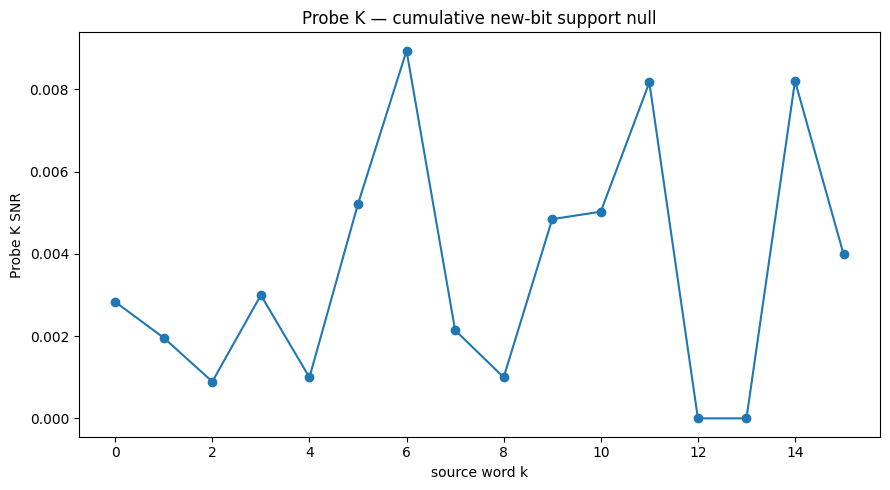

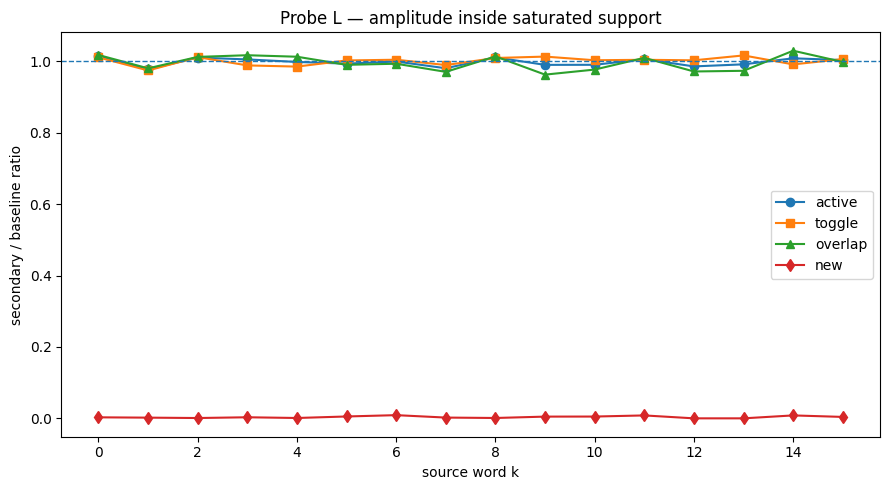

In [9]:

plt.figure(figsize=(9, 5))
plt.plot(range(16), probeK[:, 3], marker="o")
plt.xlabel("source word k")
plt.ylabel("Probe K SNR")
plt.title("Probe K — cumulative new-bit support null")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(range(16), probeL[:, 1], marker="o", label="active")
plt.plot(range(16), probeL[:, 2], marker="s", label="toggle")
plt.plot(range(16), probeL[:, 3], marker="^", label="overlap")
plt.plot(range(16), probeL[:, 4], marker="d", label="new")
plt.axhline(1.0, linestyle="--", linewidth=1)
plt.xlabel("source word k")
plt.ylabel("secondary / baseline ratio")
plt.title("Probe L — amplitude inside saturated support")
plt.legend()
plt.tight_layout()
plt.show()



### Exercise 5.1

Use the plots above to answer three questions in complete sentences:

1. Why is Probe $K$ a **support-growth null** rather than just “small”?
2. Why does Probe $L$ imply **within-saturation modulation** rather than a second amplitude wave?
3. Why do the exact-zero windows for $W[12]$ and $W[13]$ matter so much rhetorically in the paper?

Write your answers before moving on.


In [10]:

lags = list(range(10, 25))
j_prof = np.zeros((16, len(lags)), dtype=float)
c_prof = np.zeros((16, len(lags)), dtype=float)

for bit in range(512):
    w = bit // 32
    _, Sp, _ = compress_trace(flip_bit(USE_BLOCK, bit))
    masks = [state_xor_mask(S_base[r], Sp[r]) for r in range(64)]
    for li, lag in enumerate(lags):
        js, cs, n = 0.0, 0.0, 0
        for r in range(64 - lag):
            m1, m2 = masks[r], masks[r + lag]
            inter = sum(hw(m1[j] & m2[j]) for j in range(8))
            union = sum(hw(m1[j] | m2[j]) for j in range(8))
            h1 = mask_hw(m1); h2 = mask_hw(m2)
            js += inter / union if union else 0.0
            cs += inter / ((h1 * h2) ** 0.5) if h1 and h2 else 0.0
            n += 1
        j_prof[w, li] += js / n
        c_prof[w, li] += cs / n

j_prof /= 32.0
c_prof /= 32.0

i15, i16, i17 = lags.index(15), lags.index(16), lags.index(17)
j_adv = j_prof[:, i16] - 0.5 * (j_prof[:, i15] + j_prof[:, i17])
c_adv = c_prof[:, i16] - 0.5 * (c_prof[:, i15] + c_prof[:, i17])

print("Probe M mean local Jaccard advantage:", j_adv.mean())
print("Probe M mean local cosine advantage :", c_adv.mean())
print("Words peaking at lag 16:", int(np.sum(np.argmax(j_prof, axis=1) == i16)), "/16")


Probe M mean local Jaccard advantage: 0.0005437178685202809
Probe M mean local cosine advantage : 0.0006171607574449942
Words peaking at lag 16: 0 /16


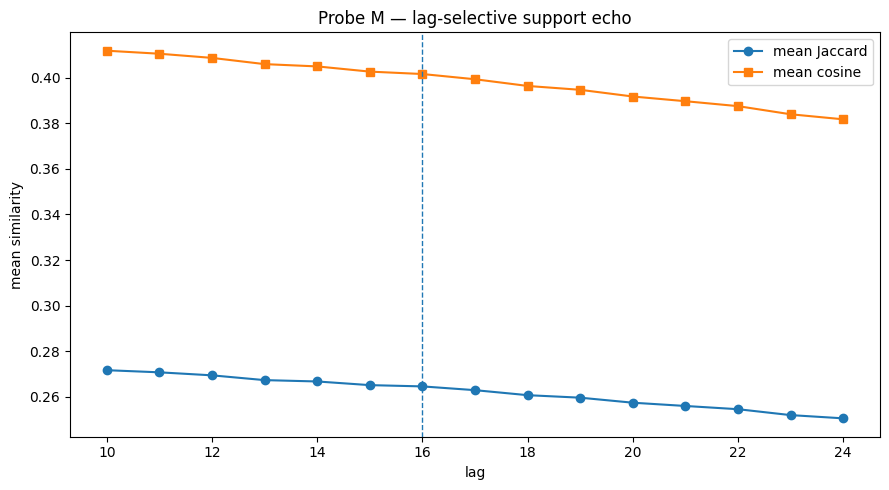

In [11]:

plt.figure(figsize=(9, 5))
plt.plot(lags, np.mean(j_prof, axis=0), marker="o", label="mean Jaccard")
plt.plot(lags, np.mean(c_prof, axis=0), marker="s", label="mean cosine")
plt.axvline(16, linestyle="--", linewidth=1)
plt.xlabel("lag")
plt.ylabel("mean similarity")
plt.title("Probe M — lag-selective support echo")
plt.legend()
plt.tight_layout()
plt.show()



### Interpretation checkpoint

Probe $M$ is the last state-space loophole.

The workbook uses the **local adjacent-lag control**:
$$
\Delta J_{16}^{\mathrm{local}}(k)=J_k(16)-\frac12\bigl[J_k(15)+J_k(17)\bigr].
$$

That is important because a global lag-16 comparison can be fooled by monotone decay.  
The paper’s strong statement here is not “lag 16 is small.” It is:

$$
\text{no systematic lag-16 outlier above its immediate neighbors}
$$

together with

$$
0/16\ \text{words peak at lag 16.}
$$


## 6. Switch basis: schedule-space echoes (Probe N)

In [12]:

def schedule_echoes(block0=USE_BLOCK):
    W0, _, _ = compress_trace(block0)
    sched_hw = np.zeros((16, 64), dtype=float)
    for bit in range(512):
        k = bit // 32
        Wp, _, _ = compress_trace(flip_bit(block0, bit))
        for t in range(64):
            sched_hw[k, t] += hw(W0[t] ^ Wp[t])
    sched_hw /= 32.0
    return W0, sched_hw

W0, sched_hw = schedule_echoes()

h0 = np.mean([sched_hw[k, k] for k in range(16)])
h16 = np.mean([sched_hw[k, k + 16] for k in range(16)])
h32 = np.mean([sched_hw[k, k + 32] for k in range(16)])
h48 = np.mean([sched_hw[k, k + 48] for k in range(16)])

print("H(k)    =", h0)
print("H(k+16) =", h16)
print("H(k+32) =", h32)
print("H(k+48) =", h48)


H(k)    = 1.0
H(k+16) = 4.91015625
H(k+32) = 15.9453125
H(k+48) = 16.107421875


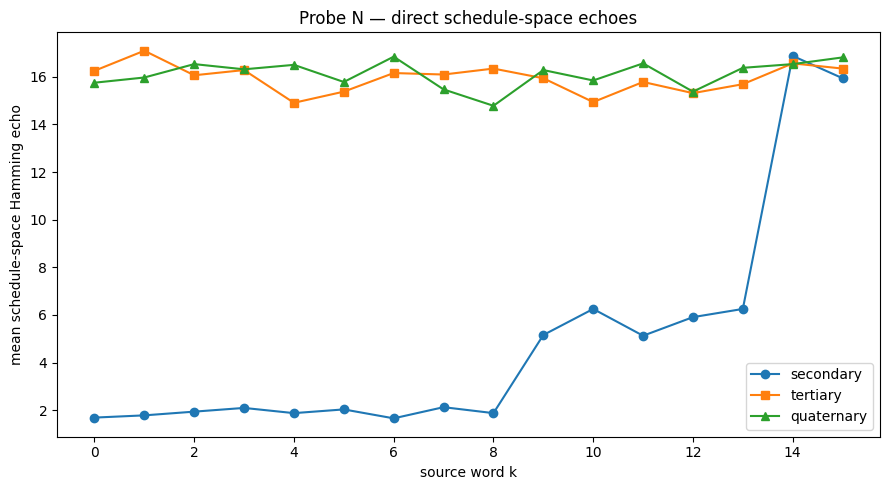

In [13]:

plt.figure(figsize=(9, 5))
plt.plot(range(16), [sched_hw[k, k + 16] for k in range(16)], marker="o", label="secondary")
plt.plot(range(16), [sched_hw[k, k + 32] for k in range(16)], marker="s", label="tertiary")
plt.plot(range(16), [sched_hw[k, k + 48] for k in range(16)], marker="^", label="quaternary")
plt.xlabel("source word k")
plt.ylabel("mean schedule-space Hamming echo")
plt.title("Probe N — direct schedule-space echoes")
plt.legend()
plt.tight_layout()
plt.show()



### Checkpoint

This is the first major basis change in the paper.

State space said:
$$
\text{no second visible support wave.}
$$

Schedule space now says:
$$
\text{the later echoes are real and strong.}
$$

This is the exact point where the paper stops being a “null result” paper and becomes a projection-law paper.


## 7. Recursive path multiplicity (Probe P)

In [14]:

P = np.zeros((64, 16), dtype=int)
for i in range(16):
    P[i, i] = 1
for i in range(16, 64):
    P[i] = P[i - 2] + P[i - 7] + P[i - 15] + P[i - 16]

sec = np.array([sched_hw[k, k + 16] for k in range(16)])
sec_paths = np.array([P[k + 16, k] for k in range(16)])
corr_sec = np.corrcoef(sec, sec_paths)[0, 1]

print("Secondary path counts:", sec_paths.tolist())
print("corr secondary amplitude vs path multiplicity:", corr_sec)


Secondary path counts: [1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 5, 5]
corr secondary amplitude vs path multiplicity: 0.9489565405932697


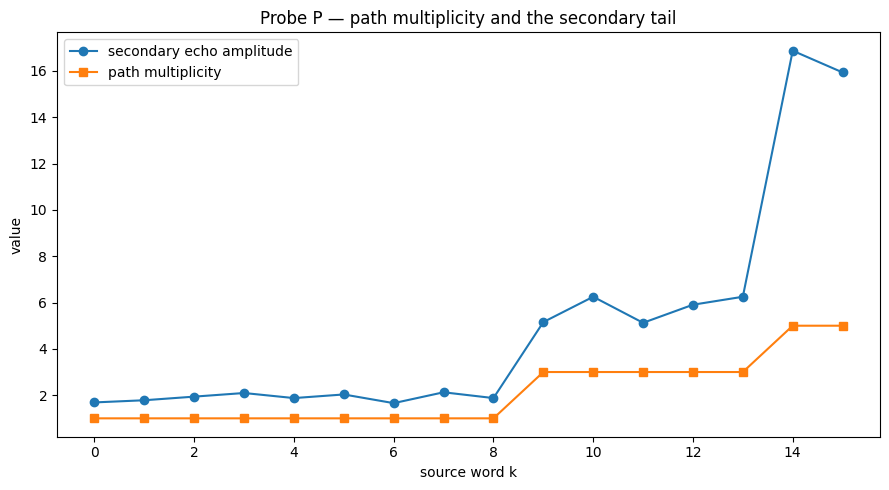

In [15]:

plt.figure(figsize=(9, 5))
plt.plot(range(16), sec, marker="o", label="secondary echo amplitude")
plt.plot(range(16), sec_paths, marker="s", label="path multiplicity")
plt.xlabel("source word k")
plt.ylabel("value")
plt.title("Probe P — path multiplicity and the secondary tail")
plt.legend()
plt.tight_layout()
plt.show()



### Exercise 7.1

Use the path counts to explain, in words and then in equations, why the secondary tail turns on in three regimes:

$$
P=1 \text{ for } k=0..8,
$$
$$
P=3 \text{ for } k=9..13,
$$
$$
P=5 \text{ for } k=14..15.
$$

Then explain why this means that “position” in SHA first means **entry time**, but later means **recursive route count**.


## 8. Capacity-gated projection law (Probe R)

In [16]:

union_hw = np.zeros((16, 64), dtype=float)
for bit in range(512):
    k = bit // 32
    _, Sp, _ = compress_trace(flip_bit(USE_BLOCK, bit))
    union = [0] * 8
    for r in range(64):
        mask = state_xor_mask(S_base[r], Sp[r])
        for j in range(8):
            union[j] |= mask[j]
        union_hw[k, r] += mask_hw(union)
union_hw /= 32.0

remaining_frac = np.clip((256.0 - union_hw) / 256.0, 0.0, 1.0)

X0 = sched_hw.reshape(-1)
Y = new_prof.reshape(-1)
C = remaining_frac.reshape(-1)

mask = X0 > 0
X0m, Ym, Cm = X0[mask], Y[mask], C[mask]

def fit_alpha(x, y):
    d = np.dot(x, x)
    return float(np.dot(x, y) / d) if d else 0.0

best = None
curve = []
betas = np.linspace(0.0, 4.0, 81)
for beta in betas:
    X = X0m * (Cm ** beta)
    alpha = fit_alpha(X, Ym)
    Yhat = alpha * X
    sse = float(np.sum((Ym - Yhat) ** 2))
    sst = float(np.sum((Ym - Ym.mean()) ** 2))
    r2 = 1.0 - sse / sst if sst > 0 else np.nan
    curve.append((beta, alpha, r2))
    if best is None or r2 > best[2]:
        best = (beta, alpha, r2)

beta_star, alpha_star, r2_star = best
alpha_plain = fit_alpha(X0m, Ym)
Yhat_plain = alpha_plain * X0m
sst = float(np.sum((Ym - Ym.mean()) ** 2))
r2_plain = 1.0 - float(np.sum((Ym - Yhat_plain) ** 2)) / sst
corr_best = float(np.corrcoef(Ym, alpha_star * X0m * (Cm ** beta_star))[0, 1])

print("alpha* =", alpha_star)
print("beta*  =", beta_star)
print("R^2 schedule only         =", r2_plain)
print("R^2 schedule × capacity^β =", r2_star)
print("corr best model           =", corr_best)


alpha* = 10.462043212344026
beta*  = 0.65
R^2 schedule only         = -0.017617613129885745
R^2 schedule × capacity^β = 0.8425332564459798
corr best model           = 0.9182567629863171


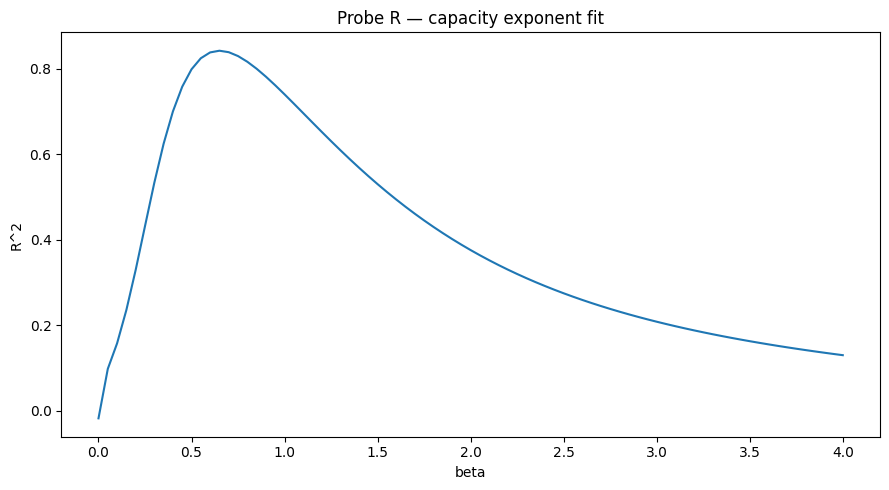

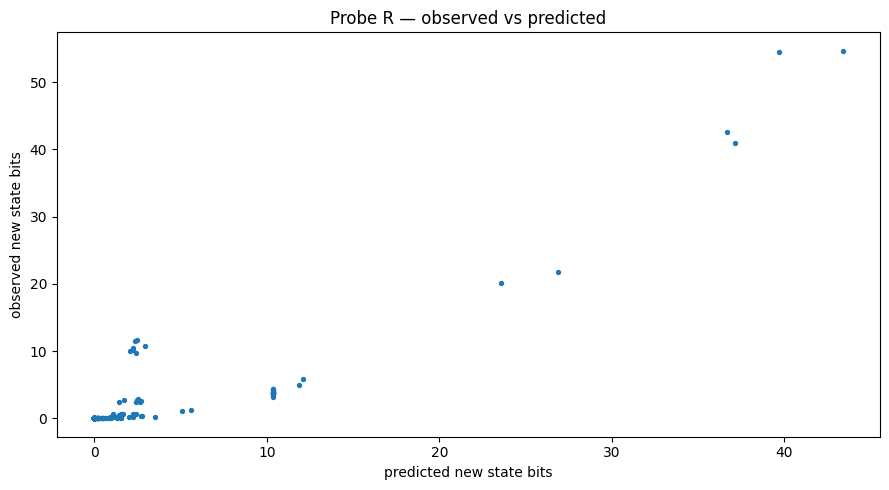

In [17]:

plt.figure(figsize=(9, 5))
plt.plot([b for b, a, r2 in curve], [r2 for b, a, r2 in curve])
plt.xlabel("beta")
plt.ylabel("R^2")
plt.title("Probe R — capacity exponent fit")
plt.tight_layout()
plt.show()

Yhat_best = alpha_star * X0m * (Cm ** beta_star)
idx = np.linspace(0, len(Ym)-1, min(4000, len(Ym)), dtype=int)
plt.figure(figsize=(9, 5))
plt.scatter(Yhat_best[idx], Ym[idx], s=8)
plt.xlabel("predicted new state bits")
plt.ylabel("observed new state bits")
plt.title("Probe R — observed vs predicted")
plt.tight_layout()
plt.show()



### Interpretation checkpoint

Probe $R$ is the bridge:
$$
N_{\mathrm{state}}(k,r)\approx \alpha^\* H_{\mathrm{sched}}(k,r) C(k,r)^{\beta^\*}.
$$

This is the point of the entire workbook.

Without capacity:
$$
\text{schedule signal alone fails}
$$

With capacity:
$$
\text{schedule signal} \times \text{remaining headroom}
$$
becomes strongly predictive.

This is why the paper says the state interface is a **capacity-gated projector** instead of a generic diffusion surface.


## 9. Workbook summary table

In [18]:

summary = {
    "Direct law early slope (inner)": float(m_early),
    "Saturation slope": float(m_sat),
    "Carry-centroid slope": float(m_cc),
    "Probe K mean SNR": float(np.nanmean(probeK[:, 3])),
    "Probe L mean active ratio": float(np.nanmean(probeL[:, 1])),
    "Probe L mean overlap ratio": float(np.nanmean(probeL[:, 3])),
    "Probe M mean local Jadv": float(np.mean(j_adv)),
    "Probe N H(k+16)": float(h16),
    "Probe N H(k+32)": float(h32),
    "Probe N H(k+48)": float(h48),
    "Probe P corr(sec,path)": float(corr_sec),
    "Probe R alpha*": float(alpha_star),
    "Probe R beta*": float(beta_star),
    "Probe R best R^2": float(r2_star),
}
for k, v in summary.items():
    print(f"{k:30s} : {v}")


Direct law early slope (inner) : -126.73972902097903
Saturation slope               : 0.7823529411764709
Carry-centroid slope           : 0.46473895742870425
Probe K mean SNR               : 0.0035755735620878887
Probe L mean active ratio      : 0.9978980841009546
Probe L mean overlap ratio     : 0.9957067523744707
Probe M mean local Jadv        : 0.0005437178685202809
Probe N H(k+16)                : 4.91015625
Probe N H(k+32)                : 15.9453125
Probe N H(k+48)                : 16.107421875
Probe P corr(sec,path)         : 0.9489565405932697
Probe R alpha*                 : 10.462043212344026
Probe R beta*                  : 0.65
Probe R best R^2               : 0.8425332564459798



## 10. Final model and writing prompts

Use the results you just reproduced to write three short summaries.

### Prompt A — direct law
Explain why word index behaves as injection time in the direct bench.

### Prompt B — state-space closure
Explain why the later echoes are **not absent**, even though Probes $K/L/M$ close the state-space question.

### Prompt C — projection law
Explain why the best current final statement is:
$$
\text{state-visible transport}
\iff
H_{\mathrm{sched}}(k,r)\,C(k,r)^{\beta^\*}\ \text{remains non-negligible}.
$$

If the reader can answer those three prompts cleanly, they understand the paper.



## 11. Optional extension cells

Below are open-ended starting points if you want to push past the paper.

1. **Deep path-law extension**
   - derive explicit closed forms or asymptotics for $P_{k+32,k}$ and $P_{k+48,k}$.

2. **Projection-law derivation**
   - replace the fitted $\alpha^\*,\beta^\*$ with a first-principles derivation attempt.

3. **Modulation threshold**
   - isolate when an echo is:
     - support-forming,
     - support-modulating,
     - or state-subcritical.

4. **Cross-block workbook extension**
   - add the exact cross-block bench to mirror the manuscript’s simultaneity null section more fully.
